<a href="https://colab.research.google.com/github/will-mccormack/CS-M148-Proj/blob/main/Final_Project_Main_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Init

In [ ]:
%pip install scikit-lego
%pip install -U kaleido
%pip install plotly
%pip install plotly --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.3/227.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 128.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import time
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import plotly.io as pio
pio.get_chrome()
pio.renderers.default = 'png'
from itertools import product
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from skimage import io, transform
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from itertools import product
from matplotlib import lines
from sklearn.linear_model import LinearRegression
from sklego.linear_model import LADRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

In [ ]:
get_ipython().system('sudo apt update && sudo apt-get install libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2')

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 https://cli.github.com/packages stable InRelease [3,917 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,202 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main am

In [ ]:
raw_data = pd.read_csv("https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv")

Read in the data

#EDA



Before splitting, check for malformed data.

In [ ]:
print(raw_data.columns)

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


First, lets check for missing values in our dataset.

In [ ]:

missing_values = raw_data.isnull().sum()

missing_percentage = (missing_values / len(raw_data)) * 100

missing_info = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})

display(missing_info)

,Missing Values,Percentage
Unnamed: 0,0,0.000000
track_id,0,0.000000
artists,1,0.000877
album_name,1,0.000877
track_name,1,0.000877
popularity,0,0.000000
duration_ms,0,0.000000
explicit,0,0.000000
danceability,0,0.000000
energy,0,0.000000


In [ ]:

missing_rows = raw_data[raw_data.isnull().any(axis=1)]

display(missing_rows)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


We see that only one entry has NaN values, for artist, album_name, and track_name. Given that it is such a small number of rows compared to the vast dataset, we can confidently remove this row / not worry about imputing it because hte overal shape of our data will basically remain the same with or without this single row.

In [ ]:
cleaned_data = raw_data.dropna()

drop_columns = ['track_id', 'Unnamed: 0']
cleaned_data = cleaned_data.drop(columns=drop_columns)

display(cleaned_data.head(5))

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Now check for NA rows again to ensure our dropping worked

In [ ]:
clean_missing_values = cleaned_data.isnull().sum()

clean_missing_values

clean_missing_percentage = (clean_missing_values / len(raw_data)) * 100

clean_missing_info = pd.DataFrame({'Missing Values': clean_missing_values, 'Percentage': clean_missing_percentage})

display(clean_missing_info)

,Missing Values,Percentage
artists,0,0.0
album_name,0,0.0
track_name,0,0.0
popularity,0,0.0
duration_ms,0,0.0
explicit,0,0.0
danceability,0,0.0
energy,0,0.0
key,0,0.0
loudness,0,0.0


NA's removed, now we can split the data and do further EDA to see what preprocessing we need to do. First we can split the data set though to avoid data leak

In [ ]:
train, test_and_validate = train_test_split(raw_data, test_size=0.4, random_state=42)
test, validate = train_test_split(test_and_validate, test_size=0.5, random_state=42)


The first thing we want to check is genre, as that seems like it could have many outliers/categories we wouldn't want to consider (i.e. podcasts, which are popular on spotify, may be counted in this dataset and we aren't concerned with these, so we would want to check). Speechiness would be a good metric to use to check for such things, so lets inspect the top most speechy songs

In [ ]:
cleaned_data.nlargest(10, "speechiness")

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18152,Tenacious D,Post-Apocalypto,turd whistle,26,39426,True,0.630,0.249,4,-14.952,1,0.965,0.353,0.0,0.193,0.739,172.243,3,comedy
18504,Tom Papa,Human Mule,The Real World,22,68758,False,0.537,0.548,5,-15.100,0,0.963,0.736,0.0,0.745,0.730,179.403,3,comedy
18530,Patton Oswalt,Talking for Clapping,Less and Less Radical,23,207619,True,0.650,0.461,7,-18.317,1,0.963,0.848,0.0,0.732,0.365,50.324,4,comedy
18137,Dan Cummins,Get Outta Here; Devil!,Get Rid of That Joke!,25,191399,True,0.604,0.619,5,-13.426,1,0.962,0.682,0.0,0.860,0.562,88.668,3,comedy
18227,Patton Oswalt,Talking for Clapping,Parents and Pills,25,202358,True,0.552,0.431,10,-18.837,1,0.962,0.872,0.0,0.674,0.448,78.361,4,comedy
18432,Robert Schimmel,Life Since Then,Chemotherapy,22,132520,True,0.599,0.369,6,-20.816,1,0.962,0.921,0.0,0.696,0.494,83.026,5,comedy
18663,Tom Papa,Human Mule,The Human Contract,21,339521,False,0.617,0.592,2,-13.854,1,0.962,0.721,0.0,0.752,0.465,90.721,4,comedy
18666,Tom Papa,Human Mule,Angry Young Men,21,136820,False,0.587,0.558,11,-14.645,0,0.962,0.795,0.0,0.807,0.559,88.127,4,comedy
18674,Tom Papa,Human Mule,Morning Tom,21,213995,False,0.526,0.667,6,-15.417,1,0.962,0.772,0.0,0.751,0.259,171.074,4,comedy
18067,Robert Schimmel,Life Since Then,Non Hogkins Lymphoma,28,68520,True,0.689,0.332,2,-19.407,1,0.961,0.873,0.0,0.660,0.701,80.739,4,comedy


Checking the found entries, we see that these indeed are comedy shows. We want to check to see if all entries with the genre "comedy" are talk shows, because if they are we can simply remove all entries labeled comedy. Lets check the lowest speechiness comedies to see if they are actual songs, or just talking

In [ ]:

lowest_speechy_comedies = train[train['track_genre'] == 'comedy'].nsmallest(10, "speechiness")
lowest_speechy_comedies


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18826,18826,6He7HGAK721bVRUv3l6hwc,"""Weird Al"" Yankovic",Polka Party,Good Enough for Now,22,183333,False,0.661,0.412,...,-13.015,1,0.0291,0.0475,0.00000,0.209,0.8550,130.758,4,comedy
18526,18526,1yk9QG4uOwZqJXM4XYA0gU,Stephen Lynch,A Little Bit Special,HermAphrodite,23,169213,True,0.483,0.424,...,-7.724,1,0.0292,0.4980,0.00000,0.100,0.2560,114.717,4,comedy
18606,18606,7u9TVTUA8uMjoZzTFThl4u,Stephen Lynch,My Old Heart,My Old Heart,22,314480,True,0.668,0.203,...,-10.825,1,0.0298,0.8890,0.00025,0.104,0.2170,138.812,4,comedy
18524,18524,4hWu7G0yGOyVgZdoMcUsYe,Steve Martin;Steep Canyon Rangers,Rare Bird Alert,More Bad Weather On The Way,22,211960,False,0.549,0.545,...,-9.162,1,0.0299,0.8010,0.17300,0.135,0.9100,127.129,4,comedy
18379,18379,12ppMTD57vkLTeQROr1XD6,Stephen Lynch,A Little Bit Special,Gerbil,24,184413,True,0.640,0.343,...,-8.999,0,0.0300,0.6780,0.00000,0.133,0.4060,109.854,4,comedy
18446,18446,7uChwK0FIUOdpu8c2AFsOx,Steve Martin;Edie Brickell,Love Has Come For You,Sun's Gonna Shine,23,185346,False,0.355,0.368,...,-9.494,1,0.0312,0.7850,0.00000,0.110,0.5010,89.530,4,comedy
18651,18651,0CaWTRBQ2MShWD7remjUfI,Jon Lajoie,You Want Some of This?,High as F%#K,38,174986,True,0.517,0.424,...,-11.046,1,0.0325,0.8660,0.00000,0.107,0.3990,139.810,4,comedy
18935,18935,526mDk6dMvJqgtMpsEy8PP,Tim Minchin,Ready For This ?,White Wine In The Sun,24,432218,False,0.402,0.248,...,-14.311,1,0.0326,0.8860,0.00000,0.685,0.1880,80.065,1,comedy
18895,18895,5FBvGDfcEshfwMMTwR1kgm,Richard Pryor;Lena Horne,The Wiz,The Good Witch Glinda,21,69000,False,0.195,0.143,...,-17.805,1,0.0346,0.9470,0.00228,0.348,0.0739,83.077,3,comedy
18401,18401,3USOTQdPtZlgVurwaqsdI5,Tenacious D,Tenacious D,Fuck Her Gently,59,123666,True,0.521,0.297,...,-7.022,1,0.0351,0.7320,0.00000,0.273,0.5170,118.681,4,comedy


We see that there are in fact some comedy songs that aren't sets. What this tells us is that for the comedy genre at least, speechiness is accurate and is not making mistakes by having comedy songs have low speechiness values. These songs accurately are comedy and have low speechiness values. This means that as a next step, we can probably find an acceptible max for speechiness and filter out all entries above that to remove podcast type entries.

The dataest description on huggingface says that most songs above 0.66 likely aren't music, and are mostly talking, so I want to test this and see if this is true. We want to be able to remove entries that are mostly just talking if possible, so need to find good threshold to do this

In [ ]:

filtered_com_speechiness = raw_data[raw_data['speechiness'] > 0.70]
filtered_com_peechiness = filtered_com_speechiness[filtered_com_speechiness['track_genre'] == 'comedy']
filtered_com_peechiness.nsmallest(10, "speechiness")

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
18846,18846,1NshHftLkdJcrMnCNqQf3U,Hva Snakker Du Om?;Anders Matthesen;Bossy Bo,Den Ka' Byttes V:O:L:01:00,Matros I Skumsprøjt Med Stormvejr og Stiv Kuli...,23,35293,False,0.698,0.438,...,-11.355,1,0.705,0.698,0.000000,0.444,0.691,139.707,3,comedy
18848,18848,1JGFhhbcEDikq0xxuAI0Mk,Kathleen Madigan,Bothering Jesus,Drinking & Ireland,21,280366,True,0.472,0.855,...,-7.011,1,0.709,0.787,0.000000,0.931,0.381,123.001,3,comedy
18508,18508,2iEc9ZUjvNz2UIbhjhD6B2,Todd Glass,Todd Glass Talks About Stuff,Health Department D's and Dinner Parties,22,336946,True,0.575,0.945,...,-2.385,1,0.712,0.839,0.000000,0.752,0.600,115.992,4,comedy
18609,18609,57x3MBUs9IE0vlZVDtrYax,Tracy Morgan,Bona Fide,Brooklyn,22,138930,True,0.385,0.951,...,-4.562,1,0.714,0.489,0.000000,0.969,0.106,178.790,4,comedy
18954,18954,5oB1UnrgyBPQLtkVWsDwI7,Clinton Jackson,Do You See the Ducks Now,The Make-up Girl,19,105626,False,0.449,0.977,...,-6.057,1,0.719,0.791,0.000000,0.427,0.177,119.938,1,comedy
18449,18449,0WVGfCs97aWDvJGBPMFMI0,Kathleen Madigan,Bothering Jesus,Car Crash vs Plane Crash,23,106001,False,0.543,0.828,...,-6.980,0,0.731,0.816,0.000000,0.748,0.691,130.355,4,comedy
18983,18983,4BB3ZRYYwRlBzNj6WUVrUj,Louis Katz,If These Balls Could Talk,Weird Sex Moves,20,104760,True,0.502,0.895,...,-4.932,1,0.731,0.884,0.000000,0.940,0.556,122.856,3,comedy
18423,18423,6aOzlhzJ5BemEkB9TXhNKo,D.L. Hughley,Notes from the G.E.D. Section,What I Learned from the News,22,125520,True,0.572,0.927,...,-5.428,1,0.732,0.780,0.000000,0.911,0.583,93.277,3,comedy
18945,18945,4wWtnRpttsyMaJBVV9ZsR7,Kathleen Madigan,Bothering Jesus,Last Call from Jail,21,194510,False,0.469,0.912,...,-7.161,0,0.733,0.779,0.000000,0.860,0.309,135.928,3,comedy
18217,18217,32Q994Bms8PgeoOBL3KViD,Stuart Thompson,Dandy Man,Gun Range,25,160257,True,0.553,0.867,...,-10.140,1,0.734,0.895,0.000003,0.600,0.866,92.780,1,comedy


Let's use .70 as a threshold. The lowest songs here are all talk shows or stand up comedy routines, so we can be pretty confident we won't accidentally remove any actual music tracks with this treshold. Some tlak shows or comedies may slip in under this, but per the datasets usage guidelines, we can assume this number shouldn't be too large such that it will mess with our dataset

Now lets check duration. Outliers should be pretty easy to remove, as few songs are extremley long or extremely short

In [ ]:
cleaned_data.nsmallest(20, "duration_ms")

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
59310,Leila Bela,Angra Manyu,The Exorsism Begins...,0,8586,False,0.000,0.0400,8,-29.714,0,0.0000,0.9280,0.95600,0.1150,0.0000,0.000,0,iranian
59812,Leila Bela,Angra Manyu,V-4,0,13386,False,0.000,0.2240,11,-22.196,1,0.0000,0.9700,0.00000,0.9070,0.0000,0.000,0,iranian
59775,Leila Bela;Leila's Opera Class,Angra Manyu,Screams for a Finale! (feat. Leila's Opera Class),0,15800,False,0.251,0.5080,5,-10.564,0,0.3160,0.9690,0.99900,0.9520,0.0000,184.051,3,iranian
16856,Wolfgang Amadeus Mozart;Ingrid Haebler,Mozart: The Complete Piano Sonatas,"Andante in C Major, K. 1a",0,17453,False,0.467,0.0301,2,-28.518,0,0.0428,0.9950,0.90000,0.1240,0.0000,84.375,4,classical
16288,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",0,17826,False,0.372,0.2780,8,-16.882,1,0.0370,0.9850,0.92100,0.1640,0.9120,89.032,1,classical
39233,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",0,17826,False,0.372,0.2780,8,-16.882,1,0.0370,0.9850,0.92100,0.1640,0.9120,89.032,1,german
59306,Leila Bela,Angra Manyu,V-7,0,21120,False,0.229,0.0577,8,-27.960,0,0.1960,0.6260,0.93100,0.1080,0.2530,172.897,4,iranian
59609,Leila Bela,Angra Manyu,Shatter,0,21240,False,0.424,0.8690,9,-8.168,0,0.0728,0.7070,0.08930,0.1170,0.0000,135.107,4,iranian
11398,Benjamin Britten;Steven Isserlis,October Classical Playlist,"Cello Suite No. 3, Op. 87: IX. Passacaglia (Ex...",0,22266,False,0.335,0.0593,11,-26.365,0,0.0430,0.9920,0.86900,0.1160,0.1950,77.266,5,british
16292,Robert Schumann;Pavel Nersessian,"Schumann, Poulenc & Others: Piano Works (Live ...","Carnaval, Op. 9: No. 13, Estrella (Live in Jap...",0,23506,False,0.379,0.2370,5,-18.265,1,0.0470,0.9930,0.88700,0.1440,0.4770,116.093,4,classical


Longest songs are dj mixes, which I guess is okay to keep. Can't see why that would warrant getting axed. There also seemt to be very few songs that are short that aren't actually songs, so I guess it's okay for them too

Another I want to check for outliers is loudness. If a track is just silent, it probably shouldn't be included.

In [ ]:
cleaned_data.nsmallest(50, "loudness")

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
101888,White Noise Sleep Sounds,Soothing White Noise,Soothing White Noise - Loopable With No Fade,32,65248,False,0.0000,0.000687,10,-49.531,0,0.0000,0.908000,0.943000,0.1010,0.00000,0.000,0,sleep
101538,White Noise Sleep Sounds,Soothing White Noise,White Noise - Loopable With No Fade,37,74217,False,0.0000,0.003320,10,-49.307,0,0.0000,0.910000,0.849000,0.1010,0.00000,0.000,0,sleep
101722,Atmosphere Asmr,Fan Sounds & White Noise 2 (Deluxe Edition),Ceiling Fan Sound on Low Power,34,120000,False,0.1620,0.004830,6,-46.591,0,0.0507,0.924000,0.965000,0.1100,0.03270,138.768,4,sleep
101360,White Noise for Babies;Crickets;Baby Sleep Sounds,Cricket Sounds,Cricket Sound 4 - Loopable With No Fade,54,71000,False,0.4610,0.003250,10,-46.251,0,0.0639,0.915000,0.862000,0.0594,0.07280,111.653,4,sleep
79719,Lazar Berman,Inedito (Unpublished),Chaconne in sol maggiore : Variazione 9,58,63840,False,0.3870,0.001810,7,-43.957,0,0.0632,0.995000,0.919000,0.0996,0.47500,98.691,4,piano
101972,Binaural Beats;White Noise Babies;Binaural Bea...,Airconditioner Noise,Nap in the Afternoon Box Fan,32,60000,False,0.1880,0.414000,1,-43.943,0,0.0720,0.996000,0.998000,0.1030,0.00994,136.862,4,sleep
101968,Relaxing Music Therapy;4D Nature Recordings;Cr...,Night Crickets for Babies,Loopable Woods,32,99778,False,0.3810,0.086000,9,-43.714,1,0.0459,0.197000,0.933000,0.1830,0.04000,137.552,3,sleep
101476,Wave Sounds For Sleep,Wave Sounds For Baby Sleep,Sleep Sound For Babies - Underwater,36,139661,False,0.2440,0.145000,10,-43.504,0,0.0494,0.970000,0.888000,0.0926,0.16200,138.094,4,sleep
79591,Brian Lyndon,Wake with me,Wake with me,60,135647,False,0.2770,0.001760,0,-43.303,1,0.0485,0.990000,0.945000,0.1030,0.07950,110.541,4,piano
101397,White Noise Babies;White Noise For Baby Sleep,Loopable White Noise,Clean White Noise - Loopable With No Fade - Wh...,39,67682,False,0.0000,0.000020,10,-43.046,1,0.0000,0.974000,0.001050,0.1010,0.00000,0.000,0,sleep


This brings to our attention the genre "sleep." Lets see how many tracks are sleep tracks

In [ ]:
sleep_tracks = train[train['track_genre'] == 'sleep']
sleep_tracks.count()


,0
Unnamed: 0,592
track_id,592
artists,592
album_name,592
track_name,592
popularity,592
duration_ms,592
explicit,592
danceability,592
energy,592


After some analysis I see that there are about 100 songs classified under the sleep genre. A LOT of them are white noise tracks, some are not. I really think that given the relative size of the dataset, and the amount of data in the sleep genre, we can just remove them all and not worry terribly about adverse effects. I will add the code that removes the sleep genre to the pre-processing section.

Based on what we found earlier, we know some genres are plainly obvious by name that thye are problematic. Let's check all the unique genres to see if anything else stands out.

In [ ]:
train["track_genre"].unique()

array(['soul', 'romance', 'metalcore', 'j-rock', 'rockabilly', 'disney',
       'samba', 'alt-rock', 'show-tunes', 'folk', 'singer-songwriter',
       'power-pop', 'guitar', 'kids', 'minimal-techno', 'malay',
       'indie-pop', 'heavy-metal', 'emo', 'new-age', 'grindcore',
       'spanish', 'hardstyle', 'mpb', 'deep-house', 'british', 'salsa',
       'edm', 'pop', 'honky-tonk', 'forro', 'iranian', 'world-music',
       'r-n-b', 'gospel', 'dub', 'indie', 'opera', 'house', 'indian',
       'ambient', 'comedy', 'hardcore', 'trance', 'punk-rock', 'garage',
       'drum-and-bass', 'alternative', 'country', 'goth', 'electronic',
       'sleep', 'songwriter', 'detroit-techno', 'industrial', 'dubstep',
       'chicago-house', 'party', 'french', 'metal', 'electro', 'hip-hop',
       'tango', 'funk', 'groove', 'hard-rock', 'pop-film', 'rock-n-roll',
       'psych-rock', 'rock', 'club', 'anime', 'punk', 'reggae',
       'afrobeat', 'dancehall', 'disco', 'dance', 'bluegrass', 'swedish',
       'c

Looks all good. Now lets check some other columns for potential issues or malformed data.

In [ ]:

checking_mode = train[~train['mode'].isin([0,1])]
checking_mode.shape

(0, 21)

No rows that have a mode that isn't 0 or 1, so valid. Nothing to remove here. Next we check key. We know that if a key is -1, no key was detected. So lets checl the nsmallest key to see if -1 was detected.

In [ ]:
train.nsmallest(20, "key")

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
45214,45214,6g4oYXbiCRAU8iPIAPR5Rm,Little Symphony,Serenity,Aurora,27,121904,False,0.178,0.0949,...,-23.573,1,0.0612,0.796000,0.848000,0.1190,0.1770,106.237,4,guitar
75219,75219,5bt2seEMbgOkzkmTMwgTKu,Michele McLaughlin,Waking the Muse,A Beautiful Distraction,50,216973,False,0.261,0.1180,...,-21.228,1,0.0418,0.969000,0.913000,0.0911,0.0528,71.055,3,new-age
113462,113462,34yDNxPkPxzG0tkpyIfHJD,Hillsong Young & Free,All Of My Best Friends,All My Life - Live,37,235880,False,0.261,0.2650,...,-9.515,1,0.0327,0.726000,0.000000,0.6730,0.1340,84.344,4,world-music
13540,13540,5AaZco2V7LgVbffczbD7kC,"Farley ""Jackmaster"" Funk",Greatest,Farley Knows House,8,262244,False,0.805,0.9230,...,-4.958,0,0.0720,0.002080,0.934000,0.0460,0.8110,120.094,4,chicago-house
13375,13375,1nS0nyQ29xPUKkaynwqSSI,Armando,100% of Dissin You Remixes,100% of Dissin You - Mike's Original Mix,10,245506,False,0.570,0.8890,...,-8.253,1,0.0777,0.003530,0.505000,0.0709,0.7820,126.261,4,chicago-house
37492,37492,5lbbKWBKV65RjUGOI8C4fd,The Supremes,A Very 60s Christmas,My Favorite Things - Stereo,0,165586,False,0.236,0.5550,...,-7.383,1,0.0310,0.039200,0.000000,0.2130,0.3250,80.718,3,funk
3564,3564,3eIL2xOWktD7xXkXoQ3uHs,FKA twigs,Daily Pop Mix,killer,0,176876,False,0.401,0.6190,...,-7.035,0,0.2100,0.168000,0.000000,0.2720,0.7570,78.763,4,alternative
99979,99979,4cAp9fEdhzLVYEgd7MnV1D,Suzan Hacigarip,Şimdi Biraz Uyu,Şimdi Biraz Uyu,42,194538,False,0.705,0.3930,...,-15.107,0,0.0350,0.295000,0.005590,0.3540,0.4590,129.990,4,singer-songwriter
14152,14152,2q4PnncxGIm1oVQzu6hS2d,Peppa Pig,My First Album,Bing Bong Zoo,55,190891,False,0.800,0.5730,...,-7.145,1,0.0501,0.600000,0.000022,0.1770,0.5390,132.108,4,children
22468,22468,1pF0MdgFm92mwM7sxJOves,Fit For An Autopsy,Oh What the Future Holds,Far from Heaven,53,284173,True,0.342,0.9680,...,-4.058,1,0.0927,0.000801,0.005660,0.3120,0.2390,91.578,4,death-metal


No undetected keys, no changes necessary.

 Lets check time signature. The dataset says that time signatures should range from 3-7, indicating 3/4 - 7/4 time signitures respectively. Lets check how many unique values there are.

In [ ]:
train["time_signature"].unique()

array([4, 3, 5, 1, 0])

In [ ]:
(train["time_signature"] < 3).sum()

np.int64(705)

Interestingly, the time signatures only go up to 4 and never to seven. This number of unique time signatures is the same amount between 3-7, but never exceed 4, so I wonder if these values are used such that 3 + time_signature represents the actual time signature. i.e. if the row has itme signature 0, its true time signature is 3 or 3/4. To check this, I can see the most popular song that is time signature 0, and google online it's time signature. If I see a trend here indicating that this is the case, we don't have to remove any songs. If This is not the case, we will have to remove any song with a time signature below 3.

In [ ]:
popular_zero_time = train[train['time_signature'] == 1]
popular_nosleep_zero_time = popular_zero_time[popular_zero_time['track_genre'] != "sleep"]
popular_nosleep_zero_time.nlargest(30, "popularity")

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
81954,81954,6jRq8gaZhMUyy5RclRPcAf,blackbear,everything means nothing,hot girl bummer,80,188343,True,0.782,0.5590,...,-7.106,0,0.0767,0.125000,0.000000,0.3850,0.6850,129.992,1,pop
57057,57057,6N22FZs2ZhPBYi3b9XPajV,Labrinth,Euphoria (Original Score from the HBO Series),Still Don't Know My Name,80,153294,False,0.316,0.6300,...,-5.963,1,0.1170,0.471000,0.262000,0.2050,0.3130,89.643,1,indie
56010,56010,6N22FZs2ZhPBYi3b9XPajV,Labrinth,Euphoria (Original Score from the HBO Series),Still Don't Know My Name,80,153294,False,0.316,0.6300,...,-5.963,1,0.1170,0.471000,0.262000,0.2050,0.3130,89.643,1,indie-pop
31012,31012,6jRq8gaZhMUyy5RclRPcAf,blackbear,everything means nothing,hot girl bummer,80,188343,True,0.782,0.5590,...,-7.106,0,0.0767,0.125000,0.000000,0.3850,0.6850,129.992,1,electro
84109,84109,0vFOzaXqZHahrZp6enQwQb,Pink Floyd,The Dark Side of the Moon,Money,73,382834,False,0.468,0.5360,...,-10.422,0,0.1440,0.024000,0.001990,0.2690,0.7850,126.256,1,psych-rock
4035,4035,3weNRklVDqb4Rr5MhKBR3D,Ludovico Einaudi,Una Mattina,Nuvole Bianche,73,357706,False,0.191,0.0582,...,-25.398,1,0.0578,0.961000,0.890000,0.0941,0.0454,132.614,1,ambient
16312,16312,3weNRklVDqb4Rr5MhKBR3D,Ludovico Einaudi,Una Mattina,Nuvole Bianche,73,357706,False,0.191,0.0582,...,-25.398,1,0.0578,0.961000,0.890000,0.0941,0.0454,132.614,1,classical
47413,47413,6s0NHplywwr1IjnQpUpWJk,George Thorogood & The Destroyers,BAD TO THE BONE,Bad To The Bone,71,292173,False,0.459,0.7270,...,-11.777,1,0.0303,0.006140,0.065200,0.3840,0.9550,149.231,1,hard-rock
8421,8421,6s0NHplywwr1IjnQpUpWJk,George Thorogood & The Destroyers,BAD TO THE BONE,Bad To The Bone,71,292173,False,0.459,0.7270,...,-11.777,1,0.0303,0.006140,0.065200,0.3840,0.9550,149.231,1,blues
51097,51097,6sPW145Y3LSXd4p1LjBOcS,Anirudh Ravichander,David,Kanave Kanave,70,284784,False,0.470,0.5130,...,-10.076,0,0.0294,0.373000,0.000006,0.1230,0.4770,95.015,1,hip-hop


Weirdly, a lot of these songs do in fact have valid time signatures when investigating. For example, "Hello Dolly" by Louis Armstrong has a time signature of 4/4 when verifying online, yet the dataset has that listed with time signature 4/4. Similarly Vance Joy's "Mess is Mine" has some parts as 4/4 and some parts 3/4, yet has time_signature "1". I want to see if this metric is unreliable for 4 time signature songs, because if so, we ought to just remove the entire column.

In [ ]:
popular_three_time = train[train['time_signature'] == 4]
popular_nosleep_three_time = popular_three_time[popular_three_time['track_genre'] != "sleep"]
popular_nosleep_three_time.nlargest(20, "popularity")

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
20001,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance
81051,81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,pop
51664,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop
88410,88410,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,reggae
89411,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,reggaeton
81210,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop
67356,67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latin
20008,20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,dance
67358,67358,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,latin
68305,68305,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Un Verano Sin Ti,Me Porto Bonito,97,178567,True,0.911,0.712,...,-5.105,0,0.0817,0.09010,0.000027,0.0933,0.425,92.005,4,latino


Honestly, cross verifying many of the time signatures with actual song time signatures found from online, the time signature detection seems to not be very accurate. We should drop the whole column.

While performing this, I realized many songs with multiple genres appear as multiple rows with the exact same stats but different genre. This could skew results. I want to see how many of the rows in our datasets consist of duplicates, and if this is a serious issue we must consider.

In [ ]:
train.shape

(68400, 21)

In [ ]:
train["track_id"].nunique()

58424

About 10k entries are duplicates. We should do something here, but we haven't reached a consensus on that yet so we will do that after that consensus is reached.

 ***DO NOT IGNORE, COME BACK TO THIS LATER AND CHANGE***

Lets check any tempo outliers

In [ ]:
low_tempo = train[train["tempo"] == 0]
low_tempo_nosleep = low_tempo[low_tempo["track_genre"] != "sleep"]
low_tempo_nosleep.shape

(11, 21)

In [ ]:
low_tempo_nosleep.nlargest(20, "popularity")

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
4131,4131,59gg6zQhSKGVnkT3hWAY3l,Max Richter;Lang Lang,Voyager - Essential Max Richter,The Departure,64,151506,False,0.0,0.03620,...,-22.519,0,0.0,0.994,0.940000,0.0958,0.0,0.0,0,ambient
64826,64826,63kd4m3VFxcJjPVVtbVNAu,Louis Armstrong,"Hello, Dolly! (Remastered)","Hello, Dolly!",62,147000,False,0.0,0.40500,...,-9.935,1,0.0,0.842,0.001140,0.1980,0.0,0.0,0,jazz
4379,4379,4acmzQsAeMJa5sGFSog7fu,Dario Marianelli;Jack Liebeck;Benjamin Wallfisch,Jane Eyre - Original Motion Picture Soundtrack,The End of Childhood (feat. Jack Liebeck),55,73266,False,0.0,0.04450,...,-26.440,0,0.0,0.972,0.972000,0.0873,0.0,0.0,0,ambient
76716,76716,7KHG8MHzxAv0YnLFBWY9Y1,Jean-Baptiste Lully;Mary Enid Haines;Sharla Na...,Lully: Ballet Music for the Sun King,Le bourgeois gentilhomme: Chaconne des Scaramo...,51,88160,False,0.0,0.01920,...,-28.821,1,0.0,0.936,0.019700,0.1380,0.0,0.0,0,opera
113428,113428,5EYzrykQ95uOmepteDi9KT,El Ruido Blanco;Soñoliento Juan;Mantra para Do...,Aire Acondicionado de Ruido Blanco,Aire de verano,27,128000,False,0.0,0.18800,...,-25.837,0,0.0,0.139,0.339000,0.1220,0.0,0.0,0,world-music
45720,45720,7i5OoyPXtSrqz9jobJfG1F,Little Symphony,Rialto Beach,Ritornello,23,102000,False,0.0,0.00129,...,-29.445,1,0.0,0.969,0.956000,0.1230,0.0,0.0,0,guitar
45729,45729,0pTAEdockvKVSq1hhFqk7O,Little Symphony,Rialto Beach,Amager,22,133624,False,0.0,0.00400,...,-28.326,1,0.0,0.970,0.959000,0.1090,0.0,0.0,0,guitar
113856,113856,6XsYJ0dwT2hRzp0Qles78F,Колыбельная-земля,Расслабляющие звуки - белый шум для вашего реб...,Пылесос (Белый шум),22,302185,False,0.0,0.22400,...,-10.224,1,0.0,0.142,0.986000,0.4110,0.0,0.0,0,world-music
45670,45670,6B9Mgf9smWqxDjA35VD6MK,Little Symphony,Rialto Beach,Campomoro,22,148711,False,0.0,0.00108,...,-30.204,1,0.0,0.952,0.991000,0.2420,0.0,0.0,0,guitar
59473,59473,48Nt8u7kYSTwE6axtE9hJO,Leila Bela,Angra Manyu,Leaving Her Quantum Journey Behind...,0,50186,False,0.0,0.03140,...,-28.194,0,0.0,0.723,0.000067,0.1290,0.0,0.0,0,iranian


Some songs have a tempo of 0, and investigating these, they seemt to just be songs where accurate analysis of their qualities never properly went through, given by them having 0 valence and time signature as well. We should just go ahead and drop these songs, as they are a relatively small number of entries and would be hard to reasonably impute.


  (NOTE: we excluse sleep songs from our anlaysis of songs above because we are already removing these songs along with all sleep genre songs)

Now that we've selected some things to remove and done basic EDA, lets quickly check a correlation matrix to see if any specific features can be removed. We already know we want to remove artists, track_id, album_name, and track_name, because we want to judge music based on the merit of the actual song and not on popuilarity associated with any particular artist name. The goal of the model is to predict a song's popularity based on it's quality, not based on it's producer. Another row we want to remove is time_signature, as determined from above metrics



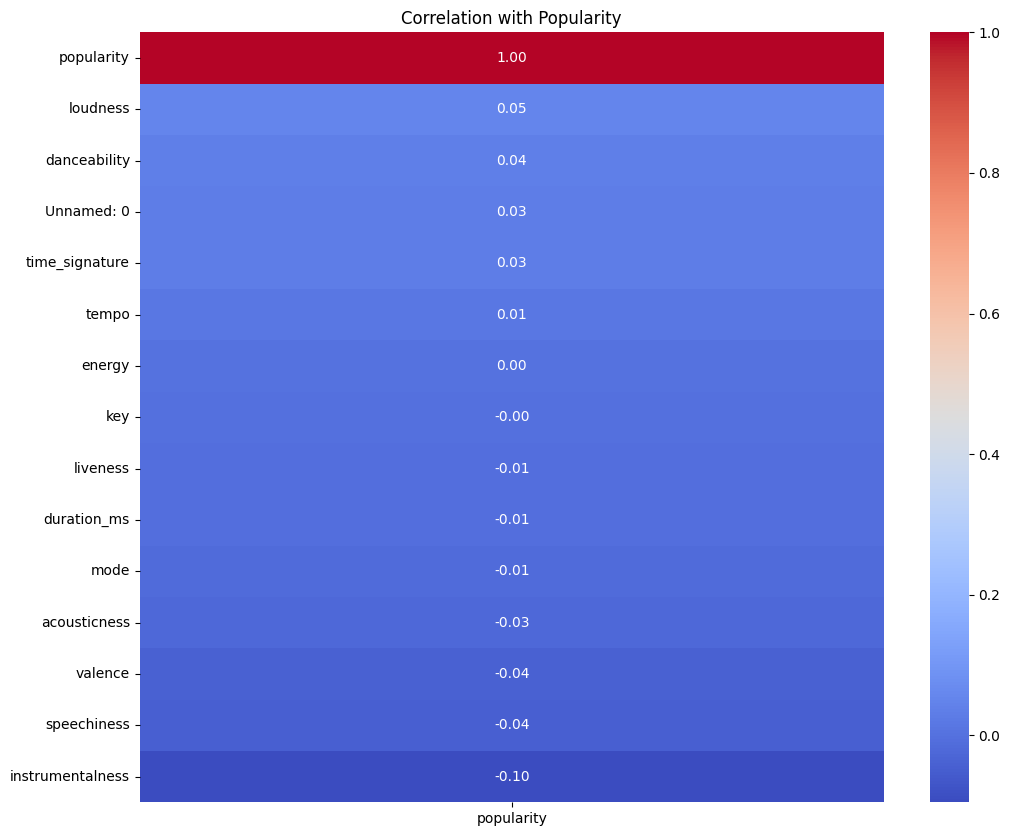

In [ ]:
numerical_cols = train.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = raw_data[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix[['popularity']].sort_values(by='popularity', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Popularity')
plt.show()

We see pretty low correlations all across the board, which is okay, because the anture of music and poopularity is complex and very likely isn't a simple linear relationship that would appear on a correlation matrix. This does help indicate what features may be nice to focus on when attempting to do linear regression, however. We can sort of predict linear regression won't be that great based on this correlation matrix, but we will still do regression for practice and in case anything jumps out during that process.

#Pre-Processing

Based on our EDA, we can go ahead and remove columns and outlier values from our data sets.

In [ ]:
def clean_df(raw_df):
  cleaned_df = raw_df.dropna()
  drop_columns = ['track_id', 'album_name', 'artists', 'track_name', 'Unnamed: 0', 'time_signature']
  cleaned_df = cleaned_df.drop(columns=drop_columns)
  cleaned_df = cleaned_df[cleaned_df['track_genre'] != 'sleep']
  cleaned_df = cleaned_df[cleaned_df["tempo"] > 10]
  cleaned_df = cleaned_df[cleaned_df["speechiness"] < 90]
  cleaned_df = cleaned_df[~(
      (cleaned_df["speechiness"] > 70) &
      (cleaned_df["track_genre"] == "comedy"))
  ]
  return cleaned_df


In [ ]:
cleaned_train = clean_df(train)
cleaned_validate = clean_df(validate)
cleaned_test = clean_df(test)


Now let's sanity check the shape of all our dfs to make sure nothing went wrong:

In [ ]:
cleaned_train.shape

(67797, 15)

In [ ]:
cleaned_validate.shape

(22580, 15)

In [ ]:
cleaned_test.shape

(22603, 15)

All good. Our preprocessing worked, and we have slimed down the data slightly and made it more workable!

#Regression Analysis



Perform regression analysis using the L1 and L2 loss functions. The first analysis involves the L1 loss function and the second involves the L2 loss functions.

In [ ]:
# training arrays
y_train = cleaned_train["popularity"].values
X_train_regression = cleaned_train.drop(columns=["popularity"])
X_train_regression = pd.get_dummies(X_train_regression, drop_first=False)
X_train_regression = X_train_regression.astype(int).values

In [ ]:
# test arrays
y_test = cleaned_test["popularity"].values
X_test = cleaned_test.drop(columns=["popularity"])
X_test = pd.get_dummies(X_test, drop_first=False)
X_test = X_test.astype(int).values

Create the linear model with the L1 loss function and fit.

---



In [ ]:
#create linear model
regression = LinearRegression()

#fit linear model
regression.fit(X_train_regression, y_train)

predicted_y = regression.predict(X_test)

Get the R^2 and MSE of the test data as well as regression slope and intercept.


In [ ]:
# R-squared on testing data
print(f"Test R^2: {regression.score(X_test, y_test):.4f}")

# MSE on test data
print(f"Test Mean Squared Error (MSE): {mean_squared_error(y_test, predicted_y):.4f}")

# Coefficients and intercept
print("Coefficients: \n", regression.coef_)  # all coefficients
print("Intercept: \n", regression.intercept_)

Test R^2: 0.2562
Test Mean Squared Error (MSE): 372.9660
Coefficients: 
 [ 1.77444685e-06  2.91321217e+00  1.61584595e-07  2.51888972e+00
 -4.24899084e-02  3.39057731e-02 -1.16993422e+00 -4.87927920e-10
  1.47671653e-09  1.44641943e-09 -2.39187215e+00  1.34012268e-09
  3.54487180e-03  9.27195703e+00 -8.70275549e+00  3.25629011e+00
 -9.56176553e+00  1.11066995e+01  1.56600431e+01 -1.14074354e+01
 -6.91516212e+00 -1.63112485e+00  1.10412427e+01 -1.32186892e+01
  1.19133145e+01  1.63038741e+00 -2.09818512e+01  2.29811034e+00
  2.06173327e+01 -1.95309801e+01  3.88076059e-01 -9.76560150e+00
 -1.54040167e+01 -1.15005767e+01 -8.32030142e-01 -1.53924893e+00
  1.08621189e+01 -2.23706745e+01  1.03511299e+00 -5.16569662e+00
 -7.25175623e+00  6.59231710e+00  8.47779230e+00  2.13725803e-01
  3.64785742e+00  1.03075513e+01  1.41946443e+01  5.81807393e+00
  8.73787250e+00  6.88625974e+00 -2.00335138e+00  7.61376248e+00
 -7.35909817e+00  8.51565734e+00 -4.38894995e+00 -1.87189302e+01
  4.68551729e+00 

Compare rMSE for cross-validation, training, and testing for different polynomial degrees.

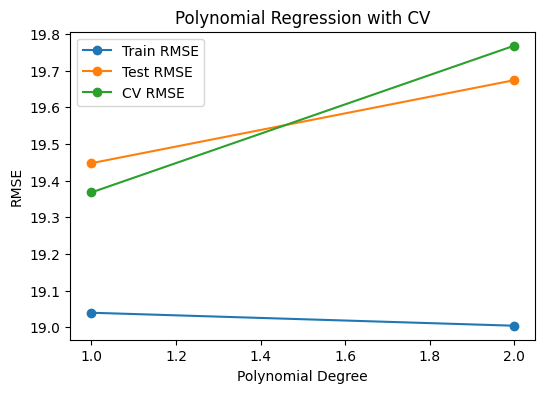

In [ ]:
n_train = 10000
X_train_small = X_train_regression[:n_train]
y_train_small = y_train[:n_train]

np.random.seed(42)

# 2-fold CV for speed (can use 3-5 for more reliable estimate)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

degrees = range(1, 3)  # small degrees for fast test
train_rmse, test_rmse, cv_rmse = [], [], []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d, include_bias=False), LinearRegression())

    # Fit on subset
    model.fit(X_train_small, y_train_small)

    # Predictions
    y_pred_train = model.predict(X_train_small)
    y_pred_test = model.predict(X_test)

    # RMSE
    train_rmse.append(np.sqrt(mean_squared_error(y_train_small, y_pred_train)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

    # Cross-validation RMSE
    cv_scores = -cross_val_score(model, X_train_small, y_train_small, cv=cv, scoring='neg_mean_squared_error')
    cv_rmse.append(np.sqrt(np.mean(cv_scores)))

# Quick plot
plt.figure(figsize=(6,4))
plt.plot(degrees, train_rmse, 'o-', label='Train RMSE')
plt.plot(degrees, test_rmse, 'o-', label='Test RMSE')
plt.plot(degrees, cv_rmse, 'o-', label='CV RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Polynomial Regression with CV')
plt.legend()
plt.show()



Create the linear model with the L2 loss function and fit.

In [ ]:
#create linear model
regression = LADRegression()

#fit linear model
regression.fit(X_train_regression, y_train)

predicted_y = regression.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklego/linear_model.py:1358: UserWarning:

Please consider using scikit-learn version of quantile regression.

Hint: `from sklearn.linear_model import QuantileRegressor`
Docs: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.QuantileRegressor.html



Get the R^2 and MSE of the test data as well as regression slope and intercept.

In [ ]:
# R-squared on testing data
print(f"Test R^2: {regression.score(X_test, y_test):.4f}")

# MSE on test data
print(f"Test Mean Squared Error (MSE): {mean_squared_error(y_test, predicted_y):.4f}")

# Coefficients and intercept
print("Coefficients: \n", regression.coef_)  # all coefficients
print("Intercept: \n", regression.intercept_)

Test R^2: 0.1798
Test Mean Squared Error (MSE): 411.2998
Coefficients: 
 [-6.87399247e-07  8.49179883e-01  0.00000000e+00  9.72087284e-02
 -1.99502121e-02  3.12729635e-02 -2.36969948e-01  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.02889603e-01  0.00000000e+00
  9.67513136e-04  1.52681090e+01 -1.16794825e+01  1.37009722e+01
 -2.40894813e+01  1.86243543e+01  1.81744590e+01 -1.25640025e+01
 -7.32204835e+00  2.36820072e+00  1.30528761e+01 -1.75556392e+01
  2.19565616e+01  2.21174332e+00 -2.25875239e+01  3.95886306e+00
  2.52047422e+01 -2.92139413e+01  5.27062190e+00 -9.49485288e+00
 -3.12158343e+01 -3.21503194e+01 -2.35399089e+00 -7.07153526e+00
  1.95486015e+01 -2.41529400e+01  1.75531579e-01 -8.95648140e+00
 -1.35576326e+01  1.16741776e+01  1.22016821e+01  3.22546550e+00
  6.53066555e+00  1.58193662e+01  1.90641483e+01  9.82379807e+00
  8.67495029e+00  4.45067874e+00  1.12231829e+01  1.99069632e+00
 -2.87351228e+00  8.65288444e+00 -7.96685915e+00 -1.81824351e+01
  8.52880041e+00 

Compare rMSE for cross-validation, training, and testing for different polynomial degrees.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error

n_train = 5000
X_train_small = X_train_regression[:n_train]
y_train_small = y_train[:n_train]

np.random.seed(42)

# 2-fold CV for speed (can use 3-5 for more reliable estimate)
cv = KFold(n_splits=2, shuffle=True, random_state=42)

degrees = range(1, 3)  # small degrees for fast test
train_rmse, test_rmse, cv_rmse = [], [], []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d, include_bias=False), LADRegression())

    # Fit on subset
    model.fit(X_train_small, y_train_small)

    # Predictions
    y_pred_train = model.predict(X_train_small)
    y_pred_test = model.predict(X_test)

    # RMSE
    train_rmse.append(np.sqrt(mean_squared_error(y_train_small, y_pred_train)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

    # Cross-validation RMSE
    cv_scores = -cross_val_score(
    model, X_train_small, y_train_small,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1  # <- run folds in parallel
)

    cv_rmse.append(np.sqrt(np.mean(cv_scores)))

# Quick plot
plt.figure(figsize=(6,4))
plt.plot(degrees, train_rmse, 'o-', label='Train RMSE')
plt.plot(degrees, test_rmse, 'o-', label='Test RMSE')
plt.plot(degrees, cv_rmse, 'o-', label='CV RMSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Polynomial Regression with CV')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklego/linear_model.py:1358: UserWarning:

Please consider using scikit-learn version of quantile regression.

Hint: `from sklearn.linear_model import QuantileRegressor`
Docs: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.QuantileRegressor.html

/usr/local/lib/python3.12/dist-packages/sklego/linear_model.py:1358: UserWarning:

Please consider using scikit-learn version of quantile regression.

Hint: `from sklearn.linear_model import QuantileRegressor`
Docs: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.QuantileRegressor.html



#Logistic Regression

# Classification - KNN

In [ ]:
cleaned_data = pd.read_csv("https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/train.csv")
validation_data = pd.read_csv("https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/validation.csv")

In [ ]:
# drop features we've determined in previous weeks
#drop_col_train = ["key","time_signature"]
drop_col = ["key","acousticness","time_signature"]
train_data = cleaned_data.drop(drop_col, axis=1)
test_data = validation_data.drop(drop_col, axis = 1)

In [ ]:
train_data.columns
test_data.columns

We are choosing to use KNN for our response variable 'explicit'

In [ ]:
from pandas.api.types import is_string_dtype
# find knn for one row
def find_knn(k, train_data, new_point, class_col, p):
  # create empty array for minkowski distance
  distance_calc = pd.Series(np.zeros(len(train_data)), index=train_data.index)
  # go through each numeric column and calculate the distance from the test data row
  for col_name in train_data.columns:
    if (col_name != class_col) and (not is_string_dtype(train_data[col_name])):
      distance_calc += abs(train_data[col_name]-new_point[col_name])**p
    else:
      continue
  distance_calc = distance_calc**(1/p) # finish distance calc
  smallest_k = distance_calc.nsmallest(k) # find smallest distance
  smallest_k_rows = smallest_k.index # find rows that correspond
  votes = train_data.loc[smallest_k_rows,class_col] # find classifiers for smallest k
  voted_class = votes.mode()[0] # get most voted class
  return voted_class

In [ ]:
from sklearn.preprocessing import StandardScaler
# find knn for entire dataset
def knn_predict(k, train_data, test_data, class_col, p):
  # find numeric columns for analysis
  numeric_cols = []
  for col_name in train_data.columns:
    if (col_name != class_col) and (not is_string_dtype(train_data[col_name])):
      numeric_cols.append(col_name)
  # scale columns so predictors on a larger scale do not dominate
  scaler = StandardScaler()
  scaler.fit(train_data[numeric_cols])
  train_scaled_np = scaler.transform(train_data[numeric_cols])
  test_scaled_np = scaler.transform(test_data[numeric_cols])
  # rearrange data into a dataframe from np.array
  train_data_scaled = train_data.copy()
  test_data_scaled = test_data.copy()
  train_data_scaled[numeric_cols] = train_scaled_np
  test_data_scaled[numeric_cols] = test_scaled_np
  # find knn vote for each row in dataset
  predictions = test_data_scaled.apply(
      lambda new_point: find_knn(k, train_data_scaled, new_point, class_col, p),
      axis=1
  )
  return predictions

Calculate knn predictions using our functions

In [ ]:
k = 3
p= 2

predictions = knn_predict(k, train_data, test_data, 'explicit', p)

predictions.head(5)

Table with true value and predicted value

In [ ]:
truth_table = pd.DataFrame({
    'truth': test_data['explicit'],
    'prediction': predictions
})

truth_table.head(5)

Get the confusion matrix.

In [ ]:
from sklearn import metrics
conf_lr = metrics.confusion_matrix(y_true=test_data['explicit'],
                                   y_pred=predictions)
conf_lr

Calculate accuracy score.

In [ ]:
(conf_lr[0, 0] + conf_lr[1, 1]) / conf_lr.sum()

Get the prediction error.

In [ ]:
1 - (conf_lr[0, 0] + conf_lr[1, 1]) / conf_lr.sum()

Get the true positive rate.

In [ ]:
# Logistic regression
(conf_lr[1, 1]) / conf_lr[1,:].sum()

Get the true negative rate.

In [ ]:
# Logistic regression
(conf_lr[0, 0]) / conf_lr[0,:].sum()

Get the F1-score.

In [ ]:
precision = conf_lr[1, 1] / conf_lr[:, 1].sum()
recall = conf_lr[1, 1] / conf_lr[1, :].sum()
f1_score = 2 * (precision * recall) / (precision + recall)
f1_score

Calc ROC curve

In [ ]:
# ROC curve
lr_fpr_sample, lr_tpr_sample, lr_thresholds_sample = metrics.roc_curve(truth_table['truth'], truth_table['prediction'])

In [ ]:
roc_lr_sample = pd.DataFrame({
    'False Positive Rate': lr_fpr_sample,
    'True Positive Rate': lr_tpr_sample,
    'Model': 'Logistic Regression'
}, index=lr_thresholds_sample)


roc_sample_df = pd.concat([roc_lr_sample])


px.line(roc_sample_df, y='True Positive Rate', x='False Positive Rate',
        color='Model',
        width=700, height=500
)

ROC curve shows that our model is predicting the data somewhat better than than a random model, since it has the right curve, it's just that the curve is not as sharp as we would like

In [ ]:
from sklearn import metrics
lr_auc_sample = metrics.roc_auc_score(truth_table['truth'], truth_table['prediction'])
print('Logistic regression AUC:', lr_auc_sample.round(3))

AUC value confirms our qualitative analysis in a quantative manner. AUC value is over 0.5, which is better than a random model, but not super close to 0.9 or higher, which would be desired. The AUC value tells us that our model is mediocre

## **Calc the k-fold cv**

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold

In [ ]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
# Create empty lists to store the results for each fold
auc_scores = []
accuracy_scores = []
threshold = 0.5
X_val = train_data.drop(['explicit','track_genre'], axis=1)
y_val = train_data['explicit']

for fold, (train_index, test_index) in enumerate(cv.split(X_val, y_val)):
    print(f"Processing fold {fold + 1}/5")

    # Split data into training and testing folds
    X_train_fold, X_test_fold = X_val.iloc[train_index], X_val.iloc[test_index]
    y_train_fold, y_test_fold = y_val.iloc[train_index], y_val.iloc[test_index]

    # Initialize and train the Logistic Regression model
    lr_fold = LogisticRegression(solver='liblinear',class_weight='balanced')
    lr_fold.fit(X_train_fold, y_train_fold)

    # Predict probabilities and binary outcomes on the test fold
    y_pred_proba_fold = lr_fold.predict_proba(X_test_fold)[:, 1]

    # Apply the threshold to get binary predictions
    y_pred_binary_fold = (lr_fold.predict(X_test_fold) > threshold).astype('float')

    # Calculate AUC and accuracy for the fold
    fold_auc = roc_auc_score(y_test_fold, y_pred_proba_fold)
    fold_accuracy = accuracy_score(y_test_fold, y_pred_binary_fold)

    # Store the results
    auc_scores.append(fold_auc)
    accuracy_scores.append(fold_accuracy)

In [ ]:
# Store the results in a DataFrame
cv_results_df = pd.DataFrame({
    'Fold': range(1, 6),
    'AUC': auc_scores,
    'Accuracy': accuracy_scores
})

# Display the results
print("Cross-validation results:")
print(cv_results_df)
print("Average values: ")
print(cv_results_df.mean())

k-fold cv AUC is 0.688, and an accuracy of 0.63 shows that our model is correctly predicting about 63% of the time. This model is mediocre but there is high variance between folds which means that the model is has instability.

# Clustering? Potentially in EDA

# PCA Transformation && NN Preprocessing

In [ ]:
train_filepath = "https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/train.csv"
validation_filepath = "https://raw.githubusercontent.com/will-mccormack/CS-M148-Proj/main/Data/validation.csv"

train_data_raw = pd.read_csv(train_filepath)
validation_data_raw = pd.read_csv(train_filepath)

In [ ]:
# device setup to find gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Load in out data. Then, one-hot encode and deal with duplicates. Algin the columns.

In [ ]:
"""
def load_data(train_path, val_path):
  train_data = pd.read_csv(train_path)
  val_data = pd.read_csv(val_path)
  train_data['explicit'] = train_data['explicit'].astype(int)
  val_data['explicit'] = val_data['explicit'].astype(int)
  train_data = pd.get_dummies(train_data, columns=['track_genre'], dtype=float)
  val_data = pd.get_dummies(val_data, columns=['track_genre'], dtype=float)
  train_cols =train_data.columns
  val_data = val_data.reindex(columns=train_cols, fill_value=0)
  return train_data, val_data
  """
def load_and_align_datasets(train_path, val_path):
    # 1. Load Data
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)

    # 2. Clean 'explicit' column (bool -> int)
    train_df['explicit'] = train_df['explicit'].astype(int)
    val_df['explicit'] = val_df['explicit'].astype(int)

    # 3. One-Hot Encode Genres (Create columns like 'track_genre_pop', 'track_genre_rock')
    train_df = pd.get_dummies(train_df, columns=['track_genre'], dtype=float)
    val_df = pd.get_dummies(val_df, columns=['track_genre'], dtype=float)

    # --- NEW: CONSOLIDATE DUPLICATES ---
    print(f"Rows before consolidation: {len(train_df)}")

    # Identify which columns are Genes vs Musical Features
    genre_cols = [c for c in train_df.columns if c.startswith('track_genre_')]
    feature_cols = [c for c in train_df.columns if c not in genre_cols]

    # Group by all musical features.
    # If two rows have identical features, they are the same song.
    # .max() combines the genre flags (0 and 1 becomes 1).
    train_df = train_df.groupby(feature_cols, as_index=False)[genre_cols].max()

    # Do the same for validation
    val_genre_cols = [c for c in val_df.columns if c.startswith('track_genre_')]
    val_feature_cols = [c for c in val_df.columns if c not in val_genre_cols]
    val_df = val_df.groupby(val_feature_cols, as_index=False)[val_genre_cols].max()

    print(f"Rows after consolidation: {len(train_df)}")
    # -----------------------------------

    # 4. Align Columns (Ensure Train and Val have same genres)
    train_cols = train_df.columns
    val_df = val_df.reindex(columns=train_cols, fill_value=0)

    return train_df, val_df

Calculate MSE, RMSE, and R^2.

In [ ]:
def calculate_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            preds = model(features).cpu().numpy() # Move to CPU for sklearn

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Convert lists to arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate Metrics
    mse = mean_squared_error(all_labels, all_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(all_labels, all_preds)

    return mse, rmse, r2

Split the data and standardize. __get__item returns a feature and label as tensors.

In [ ]:
class SpotifyDataset(Dataset):
  def __init__(self, dataframe,scaler=None,is_train=True):
    # split x and y
    self.x = dataframe.drop(columns=['popularity','instrumentalness','time_signature','valence']).values
    self.y = dataframe['popularity'].values
    if is_train:
      self.scaler = StandardScaler()
      self.x = self.scaler.fit_transform(self.x) #scale data
    else:
      self.scaler = scaler
      self.x = self.scaler.transform(self.x)

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    features = self.x[idx]
    label = self.y[idx]
    features_tensor = torch.tensor(features, dtype=torch.float32)
    label_tensor = torch.tensor(label, dtype=torch.float32)
    return features_tensor, label_tensor

Call the previous functions.

In [ ]:
train_data, val_data = load_and_align_datasets(train_filepath, validation_filepath)

train_dataset = SpotifyDataset(train_data, is_train=True)
val_dataset = SpotifyDataset(val_data, scaler=train_dataset.scaler, is_train=False)

# PCA

Apply PCA to our data.

In [ ]:
pca = PCA()
pca.fit(train_dataset.x)

Print the proportion of explained variances and the cumulative sums.

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

print(explained_variance_ratio[:10])
print(cumulative_explained_variance_ratio[:10])

Show the scree plot.

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(range(1,len(explained_variance_ratio)+1),explained_variance_ratio,label='Explained Variance',color='blue',alpha=0.7,align='center')
plt.step(range(1,len(cumulative_explained_variance_ratio)+1),cumulative_explained_variance_ratio,where='mid',label='Culumative Variance Explained',color='red')
plt.title('PCA Scree Plot')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Number')
plt.legend(loc='best')
plt.axhline(y=0.95,color='gray',linestyle='--',label='95% Threshold')
plt.xticks(range(1,len(cumulative_explained_variance_ratio)+1))
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

Convert to tensors. Batch, shuffle and load training and validation sets.

In [ ]:
x_train_transformed = pca.transform(train_dataset.x)

train_features = torch.tensor(x_train_transformed, dtype=torch.float32)
train_labels = torch.tensor(train_dataset.y, dtype=torch.float32)
train_dataset = torch.utils.data.TensorDataset(train_features, train_labels)
val_features = torch.tensor(pca.transform(val_dataset.x), dtype=torch.float32)
val_labels = torch.tensor(val_dataset.y, dtype=torch.float32)
val_dataset = torch.utils.data.TensorDataset(val_features, val_labels)

In [ ]:
BATCH_SIZE = 1024
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,pin_memory=True)

input_size = x_train_transformed.shape[1]
print(f"Input (features) size: {input_size}")

## Hyperparameter Tuning

Choose a learning rate by trainig a new model for various learning rates. Perform forward pass, backpropagation, and updates in generate the neural network. Choose the learning rate witht smallest RMSE.

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    print(f"\nTesting Learning Rate: {lr}")

    # 1. Re-initialize model (Fresh start for every LR)
    # Note: Use input_size_pca if using PCA data, or dataset.x.shape[1] if using raw data
    input_dim = input_size
    temp_model = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    ).to(device)

    optimizer = optim.Adam(temp_model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # 2. Short Training Run (e.g., 5-10 epochs is enough to see the trend)
    for epoch in range(10):
        temp_model.train()
        for features, labels in train_loader: # Use your PCA loader here
            features, labels = features.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = temp_model(features)
            loss = criterion(outputs, labels.view(-1, 1))
            loss.backward()
            optimizer.step()

    # 3. Check Validation Loss
    mse, rmse, r2 = calculate_metrics(temp_model, val_loader, device)
    results[lr] = rmse
    print(f"LR {lr} -> Validation RMSE: {rmse:.4f}")

# Find best LR
best_lr = min(results, key=results.get)
print(f"\nBest Learning Rate found: {best_lr}")

# NN Implementation

Implement a more advanced neural network. We use BatchNorm, Dropout, Silu, and a funnel-shaped design. We also use AdamE, a learning-rate scheduler, graident clipping, and early stopping to reduce overfitting. Learning rate is changed if validation loss doesn't change much.

In [ ]:
# 1. THE ADVANCED ARCHITECTURE
class SpotifyAdvancedNN(nn.Module):
    def __init__(self, input_size):
        super(SpotifyAdvancedNN, self).__init__()

        # We use a "Funnel" shape: Wide input -> narrow output
        # We use SiLU (Swish) instead of ReLU for better gradient flow

        self.network = nn.Sequential(
            # --- Layer 1: Expansion ---
            nn.Linear(input_size, 256),   # Go wide first to capture interactions
            nn.BatchNorm1d(256),          # Stabilize
            nn.SiLU(),                    # Modern activation
            nn.Dropout(0.3),              # 30% dropout to fight overfitting

            # --- Layer 2: Compression ---
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.3),

            # --- Layer 3: Deep Reasoning ---
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Dropout(0.2),

            # --- Layer 4: Fine Tuning ---
            nn.Linear(64, 32),
            nn.SiLU(),

            # --- Output Layer ---
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# 2. INITIALIZE (Assuming train_loader and device are already defined)
input_size = x_train_transformed.shape[1]
model = SpotifyAdvancedNN(input_size).to(device)

print(model)

# 3. ADVANCED OPTIMIZER & SCHEDULER
# AdamW fights overfitting better than standard Adam
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler: If validation loss doesn't improve for 5 epochs, cut LR by 10%
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

criterion = nn.MSELoss()

# 4. ROBUST TRAINING LOOP
num_epochs = 100
patience = 15 # Wait longer before early stopping
best_val_loss = float('inf')
patience_counter = 0

print("Starting Advanced Training...")

for epoch in range(num_epochs):
    # --- TRAIN ---
    model.train()
    epoch_loss = 0.0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        predictions = model(features)
        loss = criterion(predictions, labels.view(-1, 1))
        loss.backward()

        # Gradient Clipping: Prevents "exploding" gradients in deep networks
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()

    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            preds = model(features)
            v_loss = criterion(preds, labels.view(-1, 1))
            val_loss += v_loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    # STEP THE SCHEDULER
    # This tells PyTorch: "Here is the current loss, adjust LR if stuck"
    scheduler.step(avg_val_loss)

    # Logging
    current_lr = optimizer.param_groups[0]['lr']
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1} | Train: {avg_train_loss:.1f} | Val: {avg_val_loss:.1f} | LR: {current_lr:.6f}")

    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the best model state
        torch.save(model.state_dict(), 'best_spotify_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early Stopping triggered at Epoch {epoch+1}")
            break

print("Training Finished.")

Compute MSE, RMSE, and R^2.

In [ ]:
mse, rmse, r2 = calculate_metrics(model, val_loader, device)
print(f"Final Validation Results -> MSE: {mse:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

Create a scatterplot compare actual vs predicted popularity. The diagonal line represents perfect predictive capability.

In [ ]:
def plot_actual_vs_predicted(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            preds = model(features).cpu().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels)

    plt.figure(figsize=(10, 6))
    plt.scatter(all_labels, all_preds, alpha=0.1, s=1) # Alpha makes overlaps visible

    # Plot a perfect diagonal line (Ideal predictions)
    plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Prediction')

    plt.xlabel('Actual Popularity')
    plt.ylabel('Predicted Popularity')
    plt.title('Actual vs. Predicted Popularity')
    plt.legend()
    plt.show()

# Run it
plot_actual_vs_predicted(model, val_loader, device)